# IncentiveScope: PyTorch R30 retention research

## tl;dr

Can pre-cutoff trading behaviour rank later R30 participation? This companion reads the saved, frozen-data study. The summary below is computed from its results rather than prewritten to favour the neural network.

Default execution reads local results and figures. Set `INCENTIVESCOPE_RERUN_ML=1` explicitly to rebuild features and train in the separate ML environment; rerun outputs go to ignored `reports/live/ml-rerun`.

In [1]:
import json
import os
import subprocess
import sys
from pathlib import Path
from IPython.display import Markdown, SVG, display

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "Run from the repository or notebooks directory."
sys.path.insert(0, str(ROOT / "src"))
REPORT = ROOT / "reports/gmx-stip/ml"

if os.environ.get("INCENTIVESCOPE_RERUN_ML") == "1":
    ml_python = ROOT / ".venv-ml" / ("Scripts/python.exe" if os.name == "nt" else "bin/python")
    REPORT = ROOT / "reports/live/ml-rerun"
    subprocess.run([
        str(ml_python if ml_python.exists() else Path(sys.executable)),
        "-m", "incentivescope", "ml", "--config", str(ROOT / "configs/gmx-stip-ml.json"),
        "--input", str(ROOT / "data/raw/gmx-stip/trades.csv"),
        "--manifest", str(ROOT / "data/raw/gmx-stip/manifest.json"),
        "--output", str(REPORT), "--device", "cpu",
    ], cwd=ROOT, check=True)

with (REPORT / "results.json").open(encoding="utf-8") as stream:
    results = json.load(stream)
from incentivescope.ml_report import findings
primary = next(row for row in results["models"] if row["name"] == "pytorch_mlp")
display(Markdown("\n\n".join("- " + message for message in findings(results))))

- The final test contains 22,145 addresses and 954 R30 returns (4.3%).

- Primary MLP test AP is 0.3387; Histogram gradient boosting, the strongest baseline by validation AP, has test AP 0.3403.

- The MLP top 10% ranking captures 59.2% of returns, with precision 25.5% and lift 5.921× over test prevalence.

- Model selection used validation AP and selected PyTorch MLP · seed 42. MLP seed 42 was designated before final test evaluation; all three seeds are reported.

## Context & Methods

The observation is **one address × one prediction cutoff T**. Eligible accounts have a successful positive-size opening/increase during `[earning start, T)`. Features use only `timestamp < T`; the label is an opening/increase during `[T+23 days, T+30 days)` in UTC.

Training labels finish before validation begins; validation labels finish before the final test cutoff. Validation selects model settings and early-stopping epochs and is never merged back into parameter training. Seed 42 is the prespecified primary MLP run; seeds 17 and 73 remain visible.

### Key Assumptions

- This is one campaign, with training under rebates and final labels after rebates end. Predictive associations do not identify incentive causality.
- Repeated addresses at different training cutoffs are allowed; test addresses are also split by participation in parameter training.
- First observed history is bounded by the September 2023 extract. Addresses are not people.
- A later frozen indexer snapshot supports an event-time backtest; historical point-in-time indexing delays and corrections were not audited.
- No additional probability calibration is fitted. Dune agreement remains unestablished.

The MLP is `17 → 32 → 16 → 1` with ReLU, dropout 0.1, AdamW and unweighted BCEWithLogitsLoss. Compare it with training prevalence, recency ranking, Logistic Regression and HistGradientBoosting. Read [the implementation](../src/incentivescope/ml_models.py) and [the configuration](../configs/gmx-stip-ml.json) for exact recorded settings.

## Data

### Frozen inputs and temporal cutoffs

Raw input and caches are intentionally excluded from Git. To train again, restore the frozen release snapshot using the repository README, with its manifest and matching SHA-256. The default notebook requires only committed result JSON and figures.

In [2]:
from incentivescope.ml_report import label

def markdown_table(headers, rows):
    escape = lambda value: str(value).replace("|", "&#124;").replace("\n", " ")
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join("---" for _ in headers) + " |"]
    lines += ["| " + " | ".join(escape(value) for value in row) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

print("Input SHA-256:", results["dataset"]["sha256"])
print("Coverage:", results["dataset"]["coverage_start"], "to", results["dataset"]["coverage_end"], "(exclusive)")
print("Source:", results["dataset"]["source_url"])
markdown_table(["Use", "T (UTC)", "Label start", "Label end (exclusive)", "Samples", "Returns"], [
    [row["split"], row["as_of"], row["label_start"], row["label_end"], row["n"], row["positive"]]
    for row in results["split_summary"]
])
assert primary["test"]["n"] == 22145
assert primary["test"]["positives"] == 954
assert len(results["feature_names"]) == 17
print("Reference cohort reproduced: 954 / 22,145; 17 predictor columns.")

Input SHA-256: 76e4992debf0bf2e60328221c94c840aa97c2c7545550085bcd3e83d09fe61a3
Coverage: 2023-09-20T00:00:00Z to 2024-05-29T00:00:00Z (exclusive)
Source: https://gmx.squids.live/gmx-synthetics-arbitrum:prod/api/graphql


| Use | T (UTC) | Label start | Label end (exclusive) | Samples | Returns |
| --- | --- | --- | --- | --- | --- |
| train | 2023-11-22T00:00:00Z | 2023-12-15T00:00:00Z | 2023-12-22T00:00:00Z | 2197 | 560 |
| train | 2023-12-06T00:00:00Z | 2023-12-29T00:00:00Z | 2024-01-05T00:00:00Z | 4457 | 907 |
| train | 2023-12-20T00:00:00Z | 2024-01-12T00:00:00Z | 2024-01-19T00:00:00Z | 6255 | 997 |
| train | 2024-01-03T00:00:00Z | 2024-01-26T00:00:00Z | 2024-02-02T00:00:00Z | 8095 | 830 |
| train | 2024-01-17T00:00:00Z | 2024-02-09T00:00:00Z | 2024-02-16T00:00:00Z | 11363 | 1221 |
| validation | 2024-02-21T00:00:00Z | 2024-03-15T00:00:00Z | 2024-03-22T00:00:00Z | 16634 | 1598 |
| test | 2024-03-27T00:00:00Z | 2024-04-19T00:00:00Z | 2024-04-26T00:00:00Z | 22145 | 954 |

Reference cohort reproduced: 954 / 22,145; 17 predictor columns.


### Feature dictionary and reproducibility record

Counts, money and durations use `log1p`; standardisation uses training examples only. Zero-activity windows remain zero. Positive-size opening fees must be available. Account addresses, event hashes, cutoffs and labels are tracking fields, not features.

In [3]:
from incentivescope.ml_report import feature_description
markdown_table(["Feature", "Definition", "log1p"], [
    [name, feature_description(name), name in results["log_features"]]
    for name in results["feature_names"]
])
print("Training unique addresses:", results["training_unique_accounts"])
print(json.dumps(results.get("provenance", {}), indent=2))

| Feature | Definition | log1p |
| --- | --- | --- |
| opening_count_7d | Opening/increase execution count, preceding 7 days; zero if no activity. | True |
| active_days_7d | Distinct active UTC days, preceding 7 days; zero if no activity. | True |
| opening_size_usd_7d | Sum of opening/increase size, USD, preceding 7 days; zero if no activity. | True |
| opening_fee_usd_7d | Net opening position fees after trader discount, USD, preceding 7 days; zero if no activity. | True |
| opening_count_30d | Opening/increase execution count, preceding 30 days; zero if no activity. | True |
| active_days_30d | Distinct active UTC days, preceding 30 days; zero if no activity. | True |
| opening_size_usd_30d | Sum of opening/increase size, USD, preceding 30 days; zero if no activity. | True |
| opening_fee_usd_30d | Net opening position fees after trader discount, USD, preceding 30 days; zero if no activity. | True |
| opening_count_60d | Opening/increase execution count, preceding 60 days; zero if no activity. | True |
| active_days_60d | Distinct active UTC days, preceding 60 days; zero if no activity. | True |
| opening_size_usd_60d | Sum of opening/increase size, USD, preceding 60 days; zero if no activity. | True |
| opening_fee_usd_60d | Net opening position fees after trader discount, USD, preceding 60 days; zero if no activity. | True |
| days_since_first_observed_opening | Days from first observed opening to cutoff; extract-bounded history. | True |
| days_since_last_opening | Days from latest observed opening to cutoff. | True |
| pre_campaign_opening | 1 if an opening was observed before the earning window, else 0. | False |
| market_count_30d | Distinct markets with openings in the preceding 30 days. | True |
| top_market_share_30d | Largest market's share of opening USD size in the preceding 30 days; zero without openings. | False |

Training unique addresses: 11363
{
  "executed_at": "2026-10-04T07:00:46.322975Z",
  "input_sha256": "76e4992debf0bf2e60328221c94c840aa97c2c7545550085bcd3e83d09fe61a3",
  "manifest_sha256": "a0ee998e84798554d53ec8e0f3253d87a11b224dc04dfac3eb45bf4ded9513c7",
  "config_sha256": "497b7920111b8e0f735ac46f451563124274682b44a3b40bf33ef6b2f4fb8ad5",
  "config": {
    "schema_version": 1,
    "name": "GMX STIP: opening-return prediction across the earning cutoff",
    "chain_id": 42161,
    "is_synthetic": false,
    "boundary_status": "verified",
    "campaign_start": "2023-11-15T00:00:01Z",
    "campaign_end": "2024-03-27T00:00:00Z",
    "train_as_of": [
      "2023-11-22T00:00:00Z",
      "2023-12-06T00:00:00Z",
      "2023-12-20T00:00:00Z",
      "2024-01-03T00:00:00Z",
      "2024-01-17T00:00:00Z"
    ],
    "validation_as_of": "2024-02-21T00:00:00Z",
    "test_as_of": "2024-03-27T00:00:00Z",
    "expected_counts": [
      {
        "as_of": "2023-11-22T00:00:00Z",
        "n": 2197,
    

## Results

### Model comparison

AP is computed from all predictions according to `average_precision_score`; it is not trapezoidal PR-AUC. Model selection uses validation AP. A better final-test result is descriptive evidence, without a claimed significance test.

| Model | Validation AP | Test AP | ROC-AUC | Top 10% precision | Top 10% recall | Lift | Brier | Log loss |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Training prevalence | 0.0961 | 0.0431 | 0.5 | 0.046 | 0.1069 | 1.0689 | 0.0505 | 0.2286 |
| Recent activity ranking | 0.272 | 0.2177 | 0.8156 | 0.2054 | 0.4769 | 4.7683 | N/A | N/A |
| Logistic regression | 0.3874 | 0.3412 | 0.8503 | 0.256 | 0.5943 | 5.9421 | 0.0344 | 0.136 |
| Histogram gradient boosting | 0.3877 | 0.3403 | 0.8543 | 0.2528 | 0.587 | 5.8687 | 0.0351 | 0.1395 |
| PyTorch MLP · seed 42 | 0.3951 | 0.3387 | 0.8538 | 0.2551 | 0.5922 | 5.9211 | 0.0348 | 0.137 |

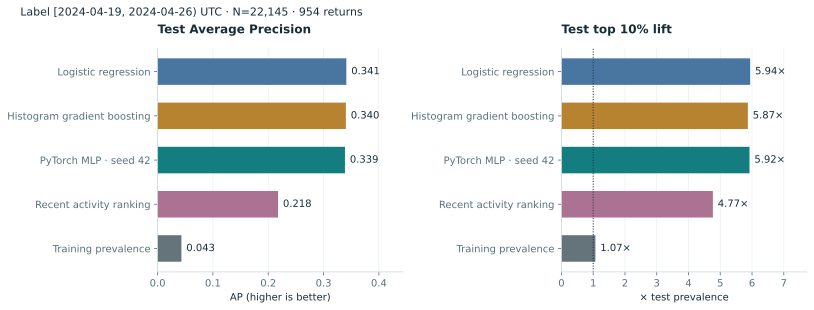

In [4]:
markdown_table(["Model", "Validation AP", "Test AP", "ROC-AUC", "Top 10% precision", "Top 10% recall", "Lift", "Brier", "Log loss"], [
    [label(row["name"]), *[round(value, 4) if value is not None else "N/A" for value in [
        row["validation"]["average_precision"], row["test"]["average_precision"], row["test"]["roc_auc"],
        row["test"]["top10_precision"], row["test"]["top10_recall"], row["test"]["top10_lift"],
        row["test"]["brier"], row["test"]["log_loss"]]]]
    for row in results["models"]
])
display(SVG(filename=str(REPORT / "figures/model-comparison.svg")))

### Precision–recall and probability reliability

Curve display points may be bounded; AP still uses the full prediction set. Reliability plots compare the primary MLP with a validation-selected probability baseline. Occupied bins display their sample counts; sparse bins should be interpreted cautiously. The recency method has ranking scores rather than probabilities.

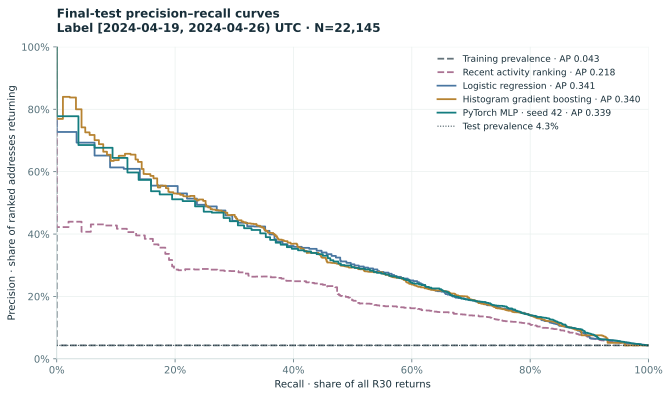

In [5]:
display(SVG(filename=str(REPORT / "figures/precision-recall.svg")))

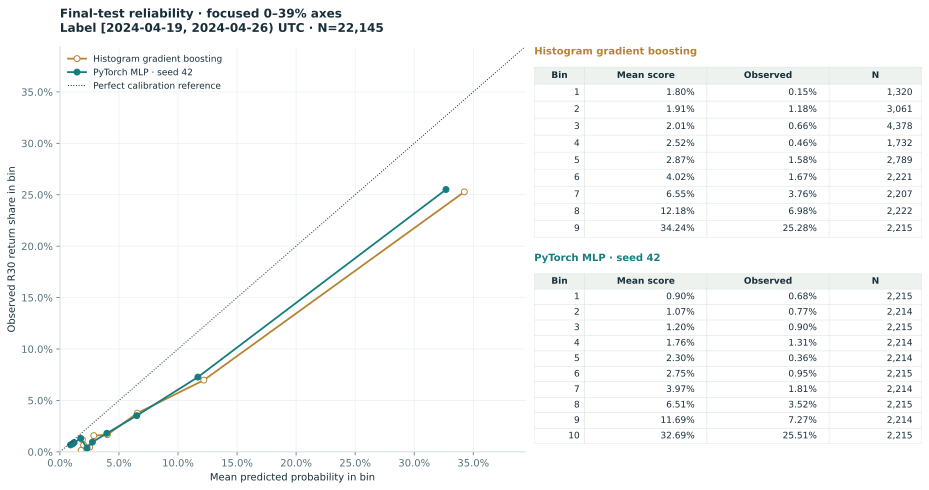

| Primary MLP mean probability | Observed return share | Bin N |
| --- | --- | --- |
| 0.009 | 0.0068 | 2215 |
| 0.0107 | 0.0077 | 2214 |
| 0.012 | 0.009 | 2215 |
| 0.0176 | 0.0131 | 2214 |
| 0.023 | 0.0036 | 2214 |
| 0.0275 | 0.0095 | 2215 |
| 0.0397 | 0.0181 | 2214 |
| 0.0651 | 0.0352 | 2215 |
| 0.1169 | 0.0727 | 2214 |
| 0.3269 | 0.2551 | 2215 |

In [6]:
display(SVG(filename=str(REPORT / "figures/reliability.svg")))
markdown_table(["Primary MLP mean probability", "Observed return share", "Bin N"], [
    [round(row["mean_probability"], 4), round(row["observed_rate"], 4), row["count"]]
    for row in primary["test"]["reliability"]
])

### Optimisation and fixed-seed variation

Epochs are selected on validation AP, not final-test results. The three seed results describe optimisation variability; they are not a statistical confidence interval.

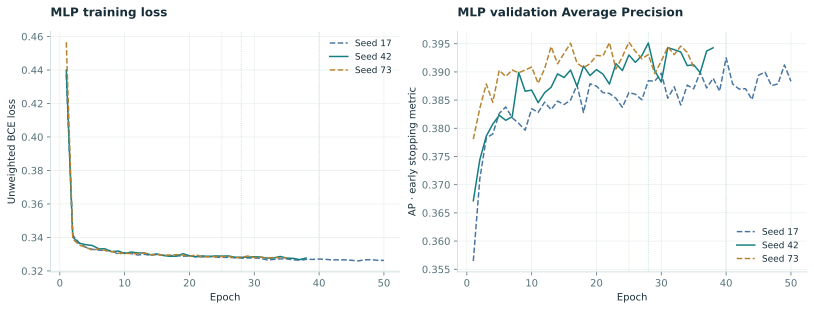

| Seed | Best epoch | Validation AP | Test AP | Test Brier |
| --- | --- | --- | --- | --- |
| 17 | 40 | 0.3925 | 0.3386 | 0.0349 |
| 42 | 28 | 0.3951 | 0.3387 | 0.0348 |
| 73 | 25 | 0.3953 | 0.3433 | 0.0352 |

In [7]:
display(SVG(filename=str(REPORT / "figures/training.svg")))
markdown_table(["Seed", "Best epoch", "Validation AP", "Test AP", "Test Brier"], [
    [row["seed"], row["best_epoch"], round(row["validation"]["average_precision"], 4),
     round(row["test"]["average_precision"], 4), round(row["test"]["brier"], 4)]
    for row in results["mlp_seed_results"]
])

### Interpreting feature dependence

Permutation importance shuffles each feature on the validation set for the primary MLP seed 42. Error bars show the standard deviation across ten shuffles, not confidence intervals. Correlated features can share importance; the values do not establish causal effects.

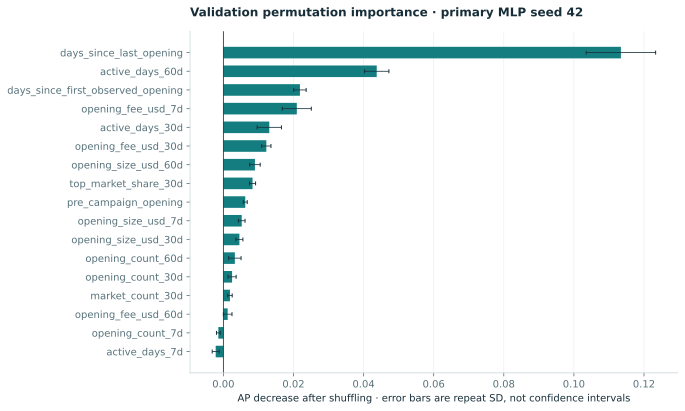

In [8]:
display(SVG(filename=str(REPORT / "figures/importance.svg")))

### Seen and unseen training addresses

“New to training” means absent from parameter-training cutoffs, and may still include addresses present in validation. This is not a claim of newly acquired traders or unique people.

In [9]:
markdown_table(["Model", "Training membership", "Returns / N", "AP", "Top 10% lift"], [
    [label(model["name"]), group, str(value["positives"]) + "/" + str(value["n"]),
     round(value["average_precision"], 4), round(value["top10_lift"], 4)]
    for model in results["models"] for group, value in model["subgroups"].items()
])

| Model | Training membership | Returns / N | AP | Top 10% lift |
| --- | --- | --- | --- | --- |
| Training prevalence | seen_in_training | 551/11363 | 0.0485 | 1.0338 |
| Training prevalence | new_to_training | 403/10782 | 0.0374 | 1.1158 |
| Recent activity ranking | seen_in_training | 551/11363 | 0.3203 | 5.8585 |
| Recent activity ranking | new_to_training | 403/10782 | 0.1776 | 4.7359 |
| Logistic regression | seen_in_training | 551/11363 | 0.3909 | 6.2575 |
| Logistic regression | new_to_training | 403/10782 | 0.2779 | 5.6038 |
| Histogram gradient boosting | seen_in_training | 551/11363 | 0.3845 | 6.1124 |
| Histogram gradient boosting | new_to_training | 403/10782 | 0.2769 | 5.4302 |
| PyTorch MLP · seed 42 | seen_in_training | 551/11363 | 0.3881 | 6.1305 |
| PyTorch MLP · seed 42 | new_to_training | 403/10782 | 0.2715 | 5.5046 |

### Editable plotting code (opt-in)

All five research figures are generated by `figures_ml` in `src/incentivescope/ml_report.py`, using standard Matplotlib from the saved result rows. Edit that function to change labels or styling, then explicitly set `INCENTIVESCOPE_RERENDER_ML=1` to render fresh SVG/PNG files into ignored `reports/live/ml-figures`. Default notebook execution only displays the reference files.

In [10]:
if os.environ.get("INCENTIVESCOPE_RERENDER_ML") == "1":
    from incentivescope.ml_report import figures_ml
    edited_assets = figures_ml(results, ROOT / "reports/live/ml-figures")
    display(SVG(filename=str(edited_assets["model-comparison"])))
else:
    print("Plot renderer is editable in src/incentivescope/ml_report.py; reference figures were read without rewriting them.")

Plot renderer is editable in src/incentivescope/ml_report.py; reference figures were read without rewriting them.


## Takeaways

The comparison must be interpreted with the shift from training under rebates to testing after rebates. A simple model can be preferable if its ranking or probability quality matches or exceeds the MLP. The project reports all results without requiring a neural-network victory. Full model-specific bins, subgroup metrics and settings remain inspectable in the JSON and portable HTML.

In [11]:
from incentivescope.ml_report import LIMITATIONS
display(Markdown("\n".join("- " + text for text in LIMITATIONS)))
print("Saved study:", REPORT / "index.html")

- This is one historical campaign and one final time holdout; it is not evidence of generalisation across protocols or campaigns.
- Training and validation labels occur while rebates are active. The final test label occurs after rebates end; prevalence and behaviour can shift.
- Repeated addresses occur at different training cutoffs. The final test separately reports addresses present and absent from parameter training.
- Addresses are not people. Keeper senders are not trader accounts; several addresses may belong to one entity.
- The label is a positive-size successful opening or increase in [T + 23 days, T + 30 days), not any return within 30 days.
- Predictions and permutation importance describe associations. They do not estimate the causal effect of incentives or justify targeting interventions.
- Scores are not additionally calibrated. Reliability plots show any probability bias; recency provides ranking scores only.
- Indexed coverage starts on 2023-09-20. First observed opening and pre-campaign history are bounded by this extract, not lifetime history.
- This event-time backtest uses a later frozen indexer snapshot. Historical point-in-time index availability and subsequent corrections were not audited.
- Dune execution and independent cross-source agreement have not been established by this ML study.

Saved study: C:\dev\hope\IncentiveScope\reports\gmx-stip\ml\index.html
